Assumed Cost of False Negative: $9588.02
Assumed Cost of False Positive: $1082.75


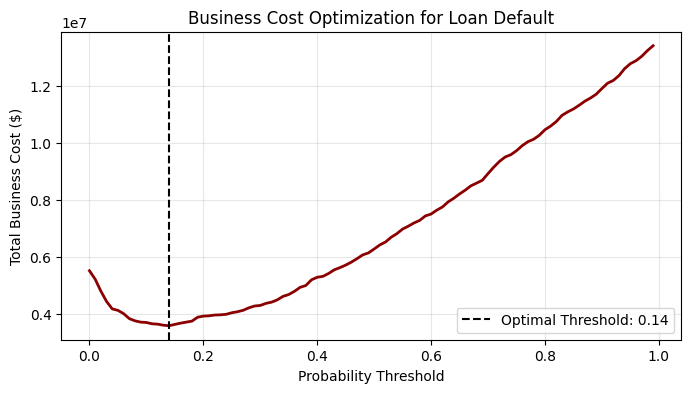


Optimal Threshold: 0.14
Minimum Total Cost achieved: $3,590,601.00

Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

           0       0.95      0.71      0.81      5099
           1       0.45      0.85      0.59      1416

    accuracy                           0.74      6515
   macro avg       0.70      0.78      0.70      6515
weighted avg       0.84      0.74      0.76      6515



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve

# Step 1: Dataset Loading and Cleaning
df = pd.read_csv('credit_risk_dataset.csv')

# Handle missing values
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# Remove outliers (e.g., age > 100 or employment length > 60 years)
df = df[df['person_age'] < 100]
df = df[df['person_emp_length'] < 60]

# Step 2: Feature Engineering & Preprocessing
# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Define X and y
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3: Model Building
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Get predicted probabilities for the default class (1)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# Step 4: Business Cost Optimization
# Define Business Costs
# Cost of FN: Loss of Principal (Average loan amount)
cost_fn = df['loan_amnt'].mean()
# Cost of FP: Opportunity loss (Lost interest profit)
cost_fp = (df['loan_amnt'] * (df['loan_int_rate']/100)).mean()

print(f"Assumed Cost of False Negative: ${cost_fn:.2f}")
print(f"Assumed Cost of False Positive: ${cost_fp:.2f}")

thresholds = np.arange(0.0, 1.0, 0.01)
total_costs = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    # Calculate total business cost
    current_cost = (fn * cost_fn) + (fp * cost_fp)
    total_costs.append(current_cost)

# Find optimal threshold
optimal_t = thresholds[np.argmin(total_costs)]
min_cost = min(total_costs)

# Step 5: Visualizations
plt.figure(figsize=(8, 4))
plt.plot(thresholds, total_costs, color='darkred', lw=2)
plt.axvline(optimal_t, color='black', linestyle='--', label=f'Optimal Threshold: {optimal_t:.2f}')
plt.title('Business Cost Optimization for Loan Default')
plt.xlabel('Probability Threshold')
plt.ylabel('Total Business Cost ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 6: Final Evaluation
y_final_pred = (y_probs >= optimal_t).astype(int)
print(f"\nOptimal Threshold: {optimal_t:.2f}")
print(f"Minimum Total Cost achieved: ${min_cost:,.2f}")
print("\nClassification Report at Optimal Threshold:")
print(classification_report(y_test, y_final_pred))